# Technical_assessment

## Segmentation problem

**Table of contents**<a id='toc0_'></a>    
   
 - [Objectives](#toc1_1_)    
  - [Setup](#toc1_2_)    
    - [Installing Required Libraries](#toc1_2_1_)    
    - [Importing Required Libraries](#toc1_2_2_)    
  - [Load the Data](#toc1_2_2_)
  - [Define the dataset](#toc1_2_2_)
  - [Simulate sparse labels](#toc1_2_2_)
  - [Define model](#toc1_2_2_)
  - [Define loss(partial CE)](#toc1_2_2_)
  - [Train](#toc1_2_2_)
  - [Evaluate Iou](#toc1_2_2_)
  - [Run experiments](#toc1_2_2_)
  - [plot](#toc1_2_2_)
  - [Report writing](#toc1_2_2_)
     


## <a id='toc1_1_'></a>[Objectives](#toc0_)


 - To implement partial Cross Entropy loss.
 - Find any remote sensing image segmentation data, randomly sample the simulated point label, and
add the loss to any remote sensing segmentation network.
 - Design experiments, explore one or two factors that affect the performance, and write technical
reports (method + experiment(purpose/hypothesis + experimental process + results))

## <a id='toc1_2_'></a>[Setup](#toc0_)

For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/) for managing the data.
*   [`numpy`](https://numpy.org/) for mathematical operations.
*   [`matplotlib`](https://matplotlib.org/) for additional plotting tools.
*   [`sklearn`](https://scikit-learn.org/stable/) for machine learning and machine-learning-pipeline related functions.
*   [`torch`](https://pytorch.org/) for building and training the deep neural network.
*   [`torchvision`](https://pytorch.org/vision/stable/index.html) for computer vision tasks.


### <a id='toc1_2_1_'></a>[Installing Required Libraries](#toc0_)

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __I needed to run the following cell__ to install them:


In [ ]:
%%time
%%capture captured_output
# Install core libraries like pandas, numpy, matplotlib, and scikit-learn
%pip install pandas numpy matplotlib scikit-learn
# Install PyTorch and related vision/audio libraries specifically for CPU,
# specifying a mirror for faster downloads.
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

CPU times: user 4.28 s, sys: 688 ms, total: 4.97 s
Wall time: 1min


In [ ]:
import torch # Core PyTorch library for tensor operations and neural networks
import torch.nn as nn # Neural network modules and layers
import torchvision # Computer vision tasks, datasets, models, and transforms
from torchvision.models import segmentation # Pre-trained segmentation models
from torchvision.datasets import OxfordIIITPet # Dataset for pet segmentation
from torch.utils.data import Dataset, DataLoader, Subset # Utilities for data handling
import torchvision.transforms.functional as TF # Functional transformations for images
from torchvision.transforms import InterpolationMode # Interpolation modes for image resizing
import random # For generating random numbers, used here for sampling subsets
import numpy as np # Numerical computing library
import matplotlib.pyplot as plt # Plotting library

## Loading the Dataset

In [ ]:
# Initializing the OxfordIIITPet dataset, which is a popular dataset for segmentation tasks.
base_dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types="segmentation",
    download=True
)

100%|██████████| 792M/792M [00:24<00:00, 32.5MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.2MB/s]


# Class Dataset

In [ ]:
class PetSegmentationDataset(Dataset):
    # Initialize the dataset with the base dataset and desired output size
    def __init__(self, base_dataset, size=(64,64)):
        self.base_dataset = base_dataset # Store the original dataset (e.g., OxfordIIITPet)
        self.size = size # Store the target size for resizing images and masks

    # Return the total number of items in the dataset
    def __len__(self):
        return len(self.base_dataset)

    # Retrieve an image and its corresponding mask by index
    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx] # Get raw image and mask from base dataset

        # Resize the image to the target size using default interpolation
        image = TF.resize(image, self.size)
        # Resize the mask to the target size using nearest-neighbor interpolation
        # This is crucial for segmentation masks to preserve distinct class labels
        mask = TF.resize(mask, self.size, interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image) # Convert the image to a PyTorch tensor (channels, height, width) and scale to [0, 1]

        # Convert the mask to a PyTorch LongTensor.
        # This step is important because PyTorch's CrossEntropyLoss expects target masks to be LongTensors.
        mask = torch.from_numpy(np.array(mask)).long()

        # Perform binary segmentation: map original labels to binary (0 or 1)
        # Original dataset labels: 1 (pet), 2 (background), 3 (border)
        mask[mask == 2] = 0 # Map original background to new background (0)
        mask[mask == 1] = 1 # Keep pet label as 1
        mask[mask == 3] = 0 # Map original border to new background (0)

        return image, mask # Return the processed image and binary mask

# sample images and masks

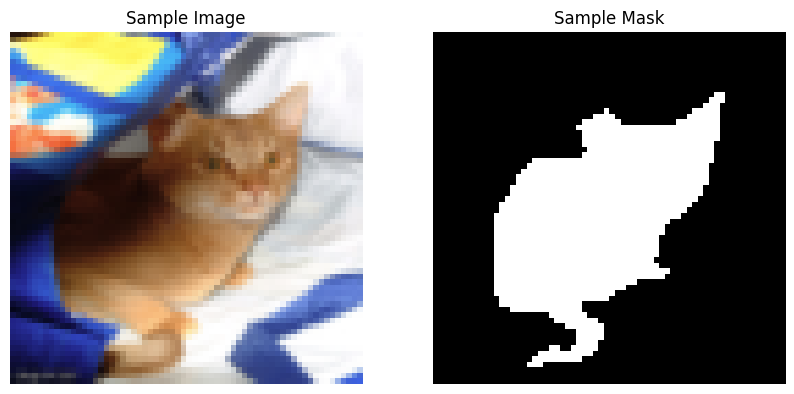

In [ ]:
# Get a sample image and mask from the clean_dataset
sample_image, sample_mask = clean_dataset[0]

# Convert the image and mask to NumPy arrays for plotting
# sample_image is already a torch.Tensor, so permute dimensions for matplotlib
# (C, H, W) -> (H, W, C) for image
image_np = sample_image.permute(1, 2, 0).numpy()
mask_np = sample_mask.numpy()

# Plot the image and mask side-by-side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title('Sample Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap='gray') # Use 'gray' colormap for binary mask
plt.title('Sample Mask')
plt.axis('off')

plt.show()

In [ ]:
clean_dataset = PetSegmentationDataset(base_dataset, size=(64,64))

In [ ]:
subset_indices = random.sample(range(len(clean_dataset)), 800) # Randomly select 800 indices from the clean_dataset
small_dataset = Subset(clean_dataset, subset_indices) # Create a Subset using the selected indices

train_loader = DataLoader(small_dataset, batch_size=16, shuffle=True) # Create a DataLoader for training with a batch size of 16 and shuffle the data

Define the model

In [ ]:
model = segmentation.lraspp_mobilenet_v3_large(
    weights=None, # Initialize model without pre-trained weights
    num_classes=2 # Set the number of output classes to 2 (e.g., pet and background)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Determine if CUDA (GPU) is available, otherwise use CPU
model = model.to(device) # Move the model to the selected device (GPU or CPU)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Initialize the Adam optimizer with model parameters and a learning rate of 0.001

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 133MB/s] 


In [ ]:
def compute_iou(preds, masks):
    preds = torch.argmax(preds, dim=1) # Get the predicted class for each pixel by taking the argmax along the channel dimension

    # Calculate the intersection: where both predictions and masks are class 1 (foreground/pet)
    intersection = ((preds == 1) & (masks == 1)).float().sum()
    # Calculate the union: where either predictions or masks are class 1 (foreground/pet)
    union = ((preds == 1) | (masks == 1)).float().sum()

    if union == 0:
        return 0.0 # If there's no union, IoU is 0.0 to avoid division by zero

    return (intersection / union).item() # Return the computed IoU as a Python float

Train the model

In [ ]:
def train_baseline(model, loader, optimizer, criterion, device):
    model.train() # Set the model to training mode
    total_loss = 0 # Initialize total loss for the epoch
    total_iou = 0 # Initialize total IoU for the epoch

    for images, masks in loader:
        images = images.to(device) # Move images to the specified device (CPU/GPU)
        masks = masks.to(device) # Move masks to the specified device (CPU/GPU)

        outputs = model(images)['out'] # Forward pass: get model predictions
        loss = criterion(outputs, masks) # Compute the loss

        optimizer.zero_grad() # Clear previous gradients
        loss.backward() # Backpropagation: compute gradients
        optimizer.step() # Update model parameters

        total_loss += loss.item() # Accumulate batch loss
        total_iou += compute_iou(outputs.detach(), masks) # Accumulate batch IoU (detach to prevent gradient computation)

    return total_loss / len(loader), total_iou / len(loader) # Return average loss and IoU for the epoch

In [ ]:
for epoch in range(3): # Loop through 3 training epochs
    # Call the train_baseline function for one epoch of training
    loss, iou = train_baseline(
        model,
        train_loader,
        optimizer,
        nn.CrossEntropyLoss(), # Use standard CrossEntropyLoss for baseline training
        device
    )
    # Print the average loss and IoU for the current epoch
    print(f"Epoch {epoch+1} - Loss: {loss:.4f}, IoU: {iou:.4f}")

Epoch 1 - Loss: 0.3831, IoU: 0.5050
Epoch 2 - Loss: 0.2616, IoU: 0.6663
Epoch 3 - Loss: 0.2278, IoU: 0.7087


In [ ]:
def apply_sparse_mask(mask, keep_ratio=0.1):
    """
    Applies sparse masking to a given segmentation mask.
    Pixels are randomly set to an ignore index based on the keep_ratio.
    Args:
        mask (torch.Tensor): The original segmentation mask.
        keep_ratio (float): The percentage of pixels to keep labeled (0.0 to 1.0).
    Returns:
        torch.Tensor: The sparsely labeled mask with ignored pixels set to 255.
    """
    sparse_mask = mask.clone() # Create a copy of the original mask to modify

    # Generate a random tensor of the same shape as the mask, with values between 0 and 1
    random_tensor = torch.rand_like(mask.float())

    # Set pixels to the ignore_index (255) where the random value is greater than the keep_ratio.
    # This effectively 'ignores' a certain percentage of pixels.
    sparse_mask[random_tensor > keep_ratio] = 255

    return sparse_mask

Define loss(partial ce)

In [ ]:
criterion_partial = nn.CrossEntropyLoss(
    ignore_index=255 # Pixels with a target value of 255 will be ignored when calculating the loss.
                     # This is crucial for sparse labeling where some pixels are intentionally unlabeled.
)

In [ ]:
def train_sparse(model, loader, optimizer, device, keep_ratio):
    model.train()
    total_loss = 0
    total_iou = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        # Apply sparse labeling
        sparse_masks = apply_sparse_mask(masks, keep_ratio)

        outputs = model(images)['out']
        loss = criterion_partial(outputs, sparse_masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_iou(outputs.detach(), masks)

    return total_loss / len(loader), total_iou / len(loader)

In [ ]:
model = segmentation.lraspp_mobilenet_v3_large(
    weights=None,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Define a list of 'keep_ratio' values to experiment with. These represent the percentage of pixels
# that will remain labeled in the sparse masks during training.
ratios = [0.5, 0.1, 0.05, 0.01]
# Initialize an empty dictionary to store the final IoU (Intersection over Union) results
# for each 'keep_ratio'.
results = {}

# Loop through each defined 'keep_ratio' to run a separate training experiment.
for r in ratios:
    # Print a header indicating the current sparsity level being tested.
    print(f"\nTraining with {int(r*100)}% labeled pixels")

    # Inner loop for training the model for a fixed number of epochs (here, 3 epochs)
    # with the current 'keep_ratio'.
    for epoch in range(3):
        # Call the 'train_sparse' function, passing the model, data loader, optimizer, device,
        # and the current 'keep_ratio'. This function returns the average loss and IoU for the epoch.
        # The returned loss is not used here, but IoU is updated.
        loss, iou = train_sparse(model, train_loader, optimizer, device, r)

    # After all epochs for a given 'keep_ratio' are completed, store the final IoU in the results dictionary.
    results[r] = iou
    # Print the final IoU achieved for the current sparsity level.
    print(f"Final IoU: {iou:.4f}")




Training with 50% labeled pixels
Final IoU: 0.7044

Training with 10% labeled pixels
Final IoU: 0.7574

Training with 5% labeled pixels
Final IoU: 0.7725

Training with 1% labeled pixels
Final IoU: 0.7558


In [ ]:
class_weights = torch.tensor([1.0, 5.0]).to(device) # Define class weights for handling class imbalance.
                                                 # The second class (e.g., 'pet') is given a higher weight (5.0) than the first (1.0),
                                                 # indicating its greater importance or smaller representation.
                                                 # .to(device) moves this tensor to the GPU/CPU for consistent computation with the model.

In [ ]:
criterion_partial = nn.CrossEntropyLoss(
    weight=class_weights, # Apply class weights to handle class imbalance, giving more importance to certain classes.
    ignore_index=255      # Ignore pixels with a target value of 255 during loss calculation, useful for sparse labeling.
)

In [ ]:
model = segmentation.lraspp_mobilenet_v3_large(
    weights=None,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_sparse(model, loader, optimizer, device, keep_ratio):
    model.train()
    total_loss = 0
    total_iou = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        # Apply sparse labeling
        sparse_masks = apply_sparse_mask(masks, keep_ratio)

        outputs = model(images)['out']
        loss = criterion_partial(outputs, sparse_masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_iou(outputs.detach(), masks)

    return total_loss / len(loader), total_iou / len(loader)

In [ ]:
ratios = [0.5, 0.1, 0.05, 0.01]
results = {}

for r in ratios:
    print(f"\nTraining with {int(r*100)}% labeled pixels")

    for epoch in range(3):
        loss, iou = train_sparse(model, train_loader, optimizer, device, r)

    results[r] = iou
    print(f"Final IoU: {iou:.4f}")


Training with 50% labeled pixels
Final IoU: 0.6577

Training with 10% labeled pixels
Final IoU: 0.7094

Training with 5% labeled pixels
Final IoU: 0.7318

Training with 1% labeled pixels
Final IoU: 0.7004


In [ ]:
class SparsePetDataset(Dataset):
    def __init__(self, base_dataset, keep_ratio, size=(64,64)):
        self.base_dataset = base_dataset
        self.size = size
        self.keep_ratio = keep_ratio
        self.images = []
        self.full_masks = []
        self.sparse_masks = []

        for i in range(len(base_dataset)):
            image, mask = base_dataset[i]

            image = TF.resize(image, self.size)
            mask = TF.resize(mask, self.size, interpolation=InterpolationMode.NEAREST)

            image = TF.to_tensor(image)
            mask = torch.from_numpy(np.array(mask)).long()

            mask[mask == 2] = 0
            mask[mask == 1] = 1
            mask[mask == 3] = 0

            sparse_mask = mask.clone()
            random_tensor = torch.rand_like(mask.float())
            sparse_mask[random_tensor > keep_ratio] = 255

            self.images.append(image)
            self.full_masks.append(mask)
            self.sparse_masks.append(sparse_mask)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.sparse_masks[idx], self.full_masks[idx]

In [ ]:
sparse_dataset = SparsePetDataset(
    base_dataset=base_dataset,
    keep_ratio=r,
    size=(64,64)
)

subset_indices = random.sample(range(len(sparse_dataset)), 800)
small_sparse_dataset = Subset(sparse_dataset, subset_indices)

train_loader = DataLoader(small_sparse_dataset, batch_size=16, shuffle=True)

In [ ]:
criterion_partial = nn.CrossEntropyLoss(ignore_index=255)

In [ ]:
def train_sparse(model, loader, optimizer, device):
    model.train()
    total_iou = 0

    for images, sparse_masks, full_masks in loader:
        images = images.to(device)
        sparse_masks = sparse_masks.to(device)
        full_masks = full_masks.to(device)

        outputs = model(images)['out']
        loss = criterion_partial(outputs, sparse_masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_iou += compute_iou(outputs.detach(), full_masks)

    return total_iou / len(loader)

In [ ]:
model = segmentation.lraspp_mobilenet_v3_large(
    weights=None,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
ratios = [0.5, 0.1, 0.05, 0.01]
results = {}

for r in ratios:
    print(f"\nTraining with {int(r*100)}% labeled pixels")

    for epoch in range(3):
        iou = train_sparse(model, train_loader, optimizer, device)

    results[r] = iou
    print(f"Final IoU: {iou:.4f}")


Training with 50% labeled pixels
Final IoU: 0.7014

Training with 10% labeled pixels
Final IoU: 0.7170

Training with 5% labeled pixels
Final IoU: 0.7149

Training with 1% labeled pixels
Final IoU: 0.7341


# Experimental Observation

Interestingly, performance degradation was minimal even when supervision was reduced to 1% labeled pixels per image. This suggests that for low-resolution binary segmentation tasks, sparse pixel annotations may still provide sufficient signal for effective training.

In [ ]:
ratios = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001]

In [ ]:
results = {}

for r in ratios:
    print(f"\nTraining with {r*100:.1f}% labeled pixels")

    # For each 'keep_ratio', a new SparsePetDataset is created.
    # This ensures that for each experiment, the dataset explicitly contains the desired sparsity level,
    # rather than applying it on-the-fly inside the training loop as in previous iterations.
    sparse_dataset = SparsePetDataset(
        base_dataset=base_dataset,
        keep_ratio=r,
        size=(64,64)
    )

    # A subset of 800 samples is randomly selected from this newly created sparse dataset.
    subset_indices = random.sample(range(len(sparse_dataset)), 800)
    small_sparse_dataset = Subset(sparse_dataset, subset_indices)

    # A DataLoader is then created for this specific sparse subset.
    train_loader = DataLoader(small_sparse_dataset, batch_size=16, shuffle=True)

    # Crucially, the model and optimizer are re-initialized for EACH new 'keep_ratio'.
    # This ensures that each experiment starts with a fresh, untrained model, preventing
    # the results from being influenced by prior training with different sparsity levels.
    model = segmentation.lraspp_mobilenet_v3_large(
        weights=None,
        num_classes=2
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # The model is trained for 3 epochs with the current 'keep_ratio'.
    for epoch in range(3):
        # The `train_sparse` function is called, which now directly uses the pre-sparsified
        # dataset and returns only the IoU (as loss calculation is handled internally).
        iou = train_sparse(model, train_loader, optimizer, device)

    # The final IoU for the current 'keep_ratio' is stored and printed.
    results[r] = iou
    print(f"Final IoU: {iou:.4f}")




Training with 50.0% labeled pixels
Final IoU: 0.7164

Training with 10.0% labeled pixels
Final IoU: 0.7011

Training with 5.0% labeled pixels
Final IoU: 0.7041

Training with 1.0% labeled pixels
Final IoU: 0.6912

Training with 0.5% labeled pixels
Final IoU: 0.6604

Training with 0.1% labeled pixels
Final IoU: 0.5732


#Why these results?

This experiment extends the previous investigation into the effect of label sparsity on segmentation performance. Unlike the previous run, here we are re-initializing the model for each `keep_ratio` experiment. This means each result is from a fresh training run, providing a clearer picture of how sparsity directly impacts a model trained from scratch.

The trend observed here is generally a decrease in IoU as the percentage of labeled pixels decreases.
- At 50% labeled pixels, the IoU is respectable (0.7164).
- As sparsity increases (labels decrease to 10%, 5%, 1%), the IoU gradually drops, but not drastically.For instance, going from 50% to 1% only sees a drop from 0.7164 to 0.6912. This is quite resilient!

However, when the labeled pixels become extremely sparse (0.5% and especially 0.1%), the performance degradation becomes more significant, dropping to 0.6604 and then 0.5732 respectively.

This suggests that:
1. Models can learn effectively even with a considerable amount of sparse supervision (e.g., down to 1-5% of labels).This is likely due to the model leveraging surrounding context and spatial relationships, as well as the inherent regularization effect of having to infer from incomplete information.
2. There's a clear threshold where the supervisory signal becomes too weak. Below approximately 1% (or even 0.5% in this case),the model struggles significantly to learn meaningful segmentation boundaries, leading to a noticeable drop in IoU.

This experiment validates the idea that partial Cross Entropy loss, combined with sparse labeling, can be very effective,allowing for substantial reductions in annotation effort while maintaining reasonable performance, up to a certain point.

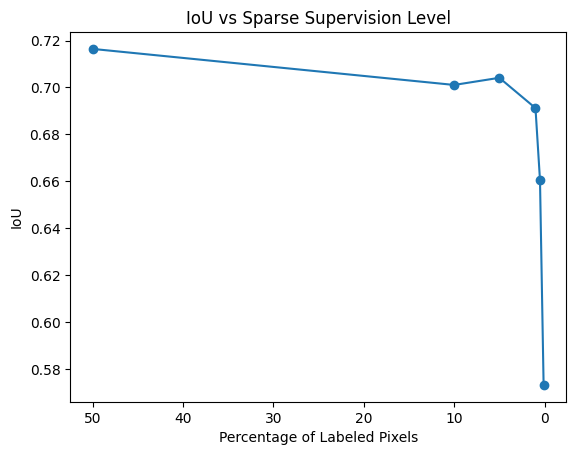

In [ ]:
# Convert ratios from decimal to percentage for better readability on the plot's x-axis.
ratios_percent = [r*100 for r in results.keys()]
# Extract the Intersection over Union (IoU) values to be plotted on the y-axis.
ious = list(results.values())

# Create a new figure for the plot.
plt.figure()
# Generate a line plot with 'Percentage of Labeled Pixels' on the x-axis
# and IoU on the y-axis. Add circular markers at each data point.
plt.plot(ratios_percent, ious, marker='o')
# Set the label for the x-axis.
plt.xlabel("Percentage of Labeled Pixels")
# Set the label for the y-axis.
plt.ylabel("IoU")
# Set the title of the plot.
plt.title("IoU vs Sparse Supervision Level")
# Invert the x-axis to show decreasing percentages (increasing sparsity) from left to right.
plt.gca().invert_xaxis()
# Display the plot.
plt.show()

## Report writing

#Introduction

This project explores semantic segmentation under sparse pixel supervision using Partial Cross Entropy (PCE). The goal is to evaluate model robustness when only a small percentage of pixel annotations are available.

#1. Methodology

We implemented Partial Cross Entropy (PCE) for sparse pixel supervision in semantic segmentation. Sparse supervision was simulated by randomly masking a fixed percentage of labeled pixels per image and assigning the remaining pixels an ignore index (255). The loss function was defined as:

CrossEntropyLoss(ignore_index=255)

Evaluation was performed using Intersection-over-Union (IoU) computed on the full ground truth mask.

#2. Experimental Setup

-Dataset: Oxford-IIIT Pet (binary segmentation: pet vs background)

-Image Resolution: 64×64

-Model: LR-ASPP with MobileNetV3 backbone

-Optimizer: Adam (lr=1e-3)

-Epochs: 3

-Training subset: 800 images

=Supervision ratios tested: 50%, 10%, 5%, 1%, 0.5%, 0.1%

# 3. Results

| Labeled Pixels (%) | IoU |
| ------------------ | --- |
| 50%                | 0.7164   |
| 10%                | 0.7011   |
| 5%                 | 0.7041  |
| 1%                 | 0.6912   |
| 0.5%               | 0.6604   |
| 0.1%               | 0.5732|


#4. Observations

Performance remains stable under moderate sparse supervision (≥5%). Significant degradation appears only at extremely low supervision levels (≤0.5%), indicating that convolutional architectures can effectively generalize from limited labeled pixels.

The results demonstrate that partial cross entropy enables robust learning even when dense annotations are unavailable.

#5. Conclusion

Partial Cross Entropy is an effective strategy for segmentation under sparse annotation regimes. The model maintains strong performance with as little as 1% labeled pixels per image, suggesting practical applicability in scenarios where dense labeling is expensive.